In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


In [3]:
df = pd.read_csv("crimes.csv")
df.head(5)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


In [7]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DR_NO         185715 non-null  int64 
 1   Date Rptd     185715 non-null  object
 2   DATE OCC      185715 non-null  object
 3   TIME OCC      185715 non-null  int64 
 4   AREA NAME     185715 non-null  object
 5   Crm Cd Desc   185715 non-null  object
 6   Vict Age      185715 non-null  int64 
 7   Vict Sex      185704 non-null  object
 8   Vict Descent  185705 non-null  object
 9   Weapon Desc   73502 non-null   object
 10  Status Desc   185715 non-null  object
 11  LOCATION      185715 non-null  object
dtypes: int64(3), object(9)
memory usage: 17.0+ MB


In [9]:
df_clean = df.copy()

df_clean.isnull().sum()

DR_NO                0
Date Rptd            0
DATE OCC             0
TIME OCC             0
AREA NAME            0
Crm Cd Desc          0
Vict Age             0
Vict Sex            11
Vict Descent        10
Weapon Desc     112213
Status Desc          0
LOCATION             0
dtype: int64

In [11]:
df_clean = df_clean.drop_duplicates()

In [15]:
df_clean["Date Rptd"] = pd.to_datetime(df_clean["Date Rptd"], errors="coerce")
df_clean["DATE OCC"] = pd.to_datetime(df_clean["DATE OCC"], errors="coerce")

In [17]:
df_clean["Vict Sex"] = df_clean["Vict Sex"].fillna("Unknown")
df_clean["Vict Descent"] = df_clean["Vict Descent"].fillna("Unknown")
df_clean["Weapon Desc"] = df_clean["Weapon Desc"].fillna("Not Reported")

In [19]:
df_clean = df_clean[df_clean["Vict Age"] > 0]

In [21]:
df_clean["TIME OCC"] = df_clean["TIME OCC"].astype(str).str.zfill(4)

In [23]:
df_clean["Hour"] = df_clean["TIME OCC"].str[:2].astype(int)

In [25]:
df_clean["Year"] = df_clean["DATE OCC"].dt.year
df_clean["Month"] = df_clean["DATE OCC"].dt.month
df_clean["Day"] = df_clean["DATE OCC"].dt.day
df_clean["Day Name"] = df_clean["DATE OCC"].dt.day_name()

In [27]:
df_clean.isnull().sum()

DR_NO           0
Date Rptd       0
DATE OCC        0
TIME OCC        0
AREA NAME       0
Crm Cd Desc     0
Vict Age        0
Vict Sex        0
Vict Descent    0
Weapon Desc     0
Status Desc     0
LOCATION        0
Hour            0
Year            0
Month           0
Day             0
Day Name        0
dtype: int64

In [29]:
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   DR_NO         185715 non-null  int64         
 1   Date Rptd     185715 non-null  datetime64[ns]
 2   DATE OCC      185715 non-null  datetime64[ns]
 3   TIME OCC      185715 non-null  object        
 4   AREA NAME     185715 non-null  object        
 5   Crm Cd Desc   185715 non-null  object        
 6   Vict Age      185715 non-null  int64         
 7   Vict Sex      185715 non-null  object        
 8   Vict Descent  185715 non-null  object        
 9   Weapon Desc   185715 non-null  object        
 10  Status Desc   185715 non-null  object        
 11  LOCATION      185715 non-null  object        
 12  Hour          185715 non-null  int32         
 13  Year          185715 non-null  int32         
 14  Month         185715 non-null  int32         
 15  Day           185

##Data Dictionary

In [33]:
data_dictionary = pd.DataFrame({
    "Column": df_clean.columns,
    "Data Type": df_clean.dtypes.values,
    "Missing Values": df_clean.isnull().sum().values,
    "Unique Values": df_clean.nunique().values
})

data_dictionary

,Column,Data Type,Missing Values,Unique Values
0,DR_NO,int64,0,185715
1,Date Rptd,datetime64[ns],0,398
2,DATE OCC,datetime64[ns],0,1152
3,TIME OCC,object,0,1439
4,AREA NAME,object,0,21
5,Crm Cd Desc,object,0,104
6,Vict Age,int64,0,98
7,Vict Sex,object,0,5
8,Vict Descent,object,0,21
9,Weapon Desc,object,0,75


##ERD

In [36]:
df_clean.shape

(185715, 17)

In [38]:
df_clean.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA NAME',
       'Crm Cd Desc', 'Vict Age', 'Vict Sex', 'Vict Descent', 'Weapon Desc',
       'Status Desc', 'LOCATION', 'Hour', 'Year', 'Month', 'Day', 'Day Name'],
      dtype='object')

In [40]:
df_clean.dtypes

DR_NO                    int64
Date Rptd       datetime64[ns]
DATE OCC        datetime64[ns]
TIME OCC                object
AREA NAME               object
Crm Cd Desc             object
Vict Age                 int64
Vict Sex                object
Vict Descent            object
Weapon Desc             object
Status Desc             object
LOCATION                object
Hour                     int32
Year                     int32
Month                    int32
Day                      int32
Day Name                object
dtype: object

In [42]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   DR_NO         185715 non-null  int64         
 1   Date Rptd     185715 non-null  datetime64[ns]
 2   DATE OCC      185715 non-null  datetime64[ns]
 3   TIME OCC      185715 non-null  object        
 4   AREA NAME     185715 non-null  object        
 5   Crm Cd Desc   185715 non-null  object        
 6   Vict Age      185715 non-null  int64         
 7   Vict Sex      185715 non-null  object        
 8   Vict Descent  185715 non-null  object        
 9   Weapon Desc   185715 non-null  object        
 10  Status Desc   185715 non-null  object        
 11  LOCATION      185715 non-null  object        
 12  Hour          185715 non-null  int32         
 13  Year          185715 non-null  int32         
 14  Month         185715 non-null  int32         
 15  Day           185

In [44]:
df_clean.describe()

,DR_NO,Date Rptd,DATE OCC,Vict Age,Hour,Year,Month,Day
count,1.857150e+05,185715,185715,185715.000000,185715.000000,185715.000000,185715.000000,185715.000000
mean,2.255781e+08,2022-12-12 01:50:25.325902848,2022-11-27 19:04:55.711170560,39.999257,12.813079,2022.411114,6.516076,14.775549
min,2.009072e+08,2022-06-01 00:00:00,2020-01-01 00:00:00,2.000000,0.000000,2020.000000,1.000000,1.000000
25%,2.210108e+08,2022-09-04 00:00:00,2022-08-25 00:00:00,28.000000,8.000000,2022.000000,4.000000,7.000000
50%,2.220114e+08,2022-12-10 00:00:00,2022-12-02 00:00:00,37.000000,13.000000,2022.000000,6.000000,15.000000
75%,2.310044e+08,2023-03-20 00:00:00,2023-03-12 00:00:00,50.000000,18.000000,2023.000000,9.000000,23.000000
max,2.399097e+08,2023-07-03 00:00:00,2023-07-03 00:00:00,99.000000,23.000000,2023.000000,12.000000,31.000000
std,5.017438e+06,NaN,NaN,15.450227,6.551456,0.527180,3.329724,9.112616


In [46]:
df_clean["Crm Cd Desc"].value_counts().head(10)

Crm Cd Desc
THEFT OF IDENTITY                                           22670
BATTERY - SIMPLE ASSAULT                                    19694
BURGLARY FROM VEHICLE                                       13799
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT              13215
INTIMATE PARTNER - SIMPLE ASSAULT                           11981
THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)         11484
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)     10719
THEFT PLAIN - PETTY ($950 & UNDER)                          10603
BURGLARY                                                    10268
THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD     7057
Name: count, dtype: int64

In [48]:
df_clean["AREA NAME"].value_counts().head(10)

AREA NAME
Central        14944
Southwest      11945
77th Street    11739
Pacific         9923
Hollywood       9762
Southeast       9571
Olympic         9414
Newton          9152
Van Nuys        8621
N Hollywood     8502
Name: count, dtype: int64

In [50]:
df_clean["Hour"].value_counts().sort_index()

Hour
0      8728
1      5836
2      4726
3      3943
4      3238
5      3171
6      5621
7      5403
8      7523
9      7092
10     8440
11     8787
12    13663
13     8474
14     8872
15     9393
16     9224
17     9964
18    10125
19     9262
20     9579
21     8701
22     8531
23     7419
Name: count, dtype: int64

In [52]:
df_clean["Day Name"].value_counts()

Day Name
Friday       28625
Saturday     27469
Thursday     26694
Wednesday    26497
Sunday       25716
Monday       25671
Tuesday      25043
Name: count, dtype: int64

In [54]:
df_clean["Month"].value_counts().sort_index()

Month
1     14755
2     13626
3     13854
4     13505
5     14505
6     26997
7     15430
8     14891
9     14312
10    15110
11    13769
12    14961
Name: count, dtype: int64

In [56]:
df_clean["Vict Sex"].value_counts()

Vict Sex
M          93008
F          89854
X           2812
H             30
Unknown       11
Name: count, dtype: int64

In [58]:
df_clean["Vict Age"].describe()

count    185715.000000
mean         39.999257
std          15.450227
min           2.000000
25%          28.000000
50%          37.000000
75%          50.000000
max          99.000000
Name: Vict Age, dtype: float64

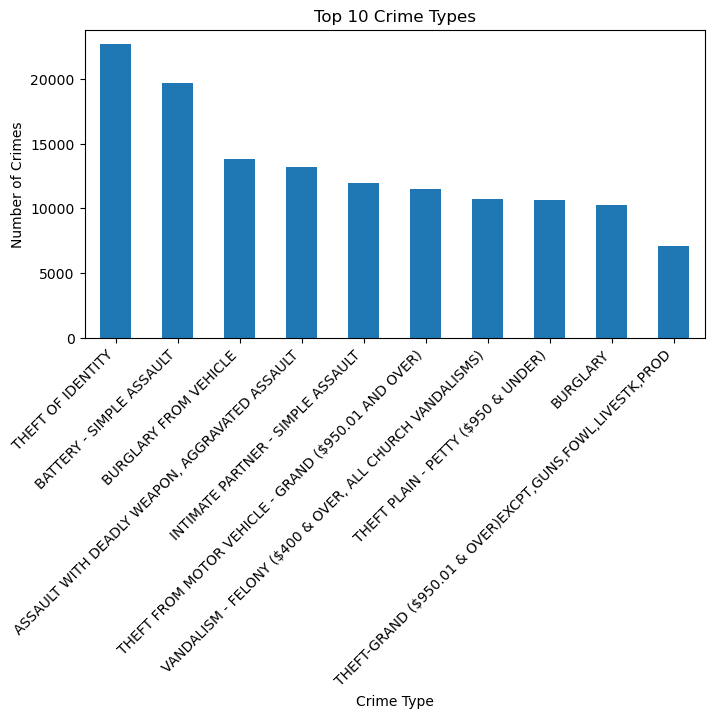

In [80]:
plt.figure(figsize=(8, 4))

df_clean["Crm Cd Desc"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45, ha="right")
plt.show()

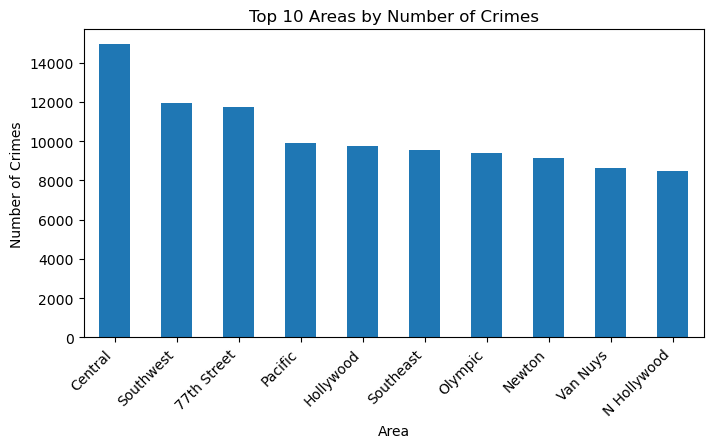

In [78]:
plt.figure(figsize=(8, 4))

df_clean["AREA NAME"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Areas by Number of Crimes")
plt.xlabel("Area")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45, ha="right")
plt.show()

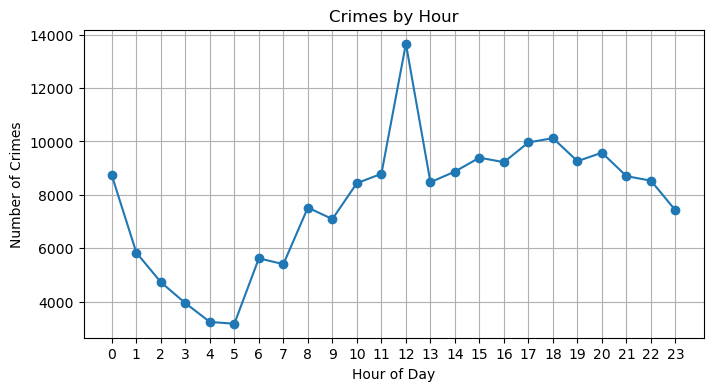

In [76]:
plt.figure(figsize=(8, 4))

df_clean["Hour"].value_counts().sort_index().plot(kind="line", marker="o")

plt.title("Crimes by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crimes")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

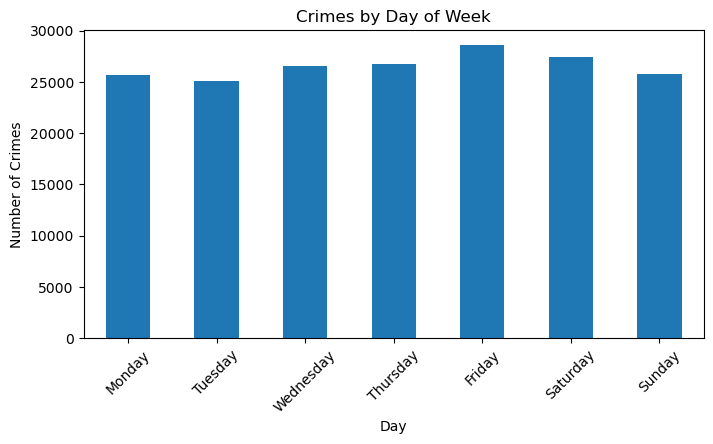

In [74]:
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(8, 4))

df_clean["Day Name"].value_counts().reindex(days_order).plot(kind="bar")

plt.title("Crimes by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)
plt.show()

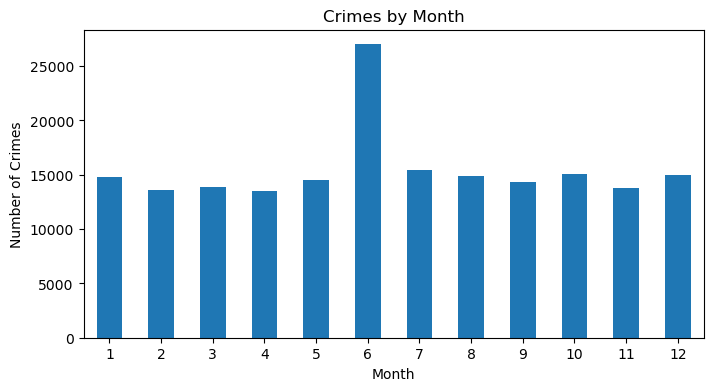

In [82]:
plt.figure(figsize=(8, 4))

df_clean["Month"].value_counts().sort_index().plot(kind="bar")

plt.title("Crimes by Month")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=0)
plt.show()

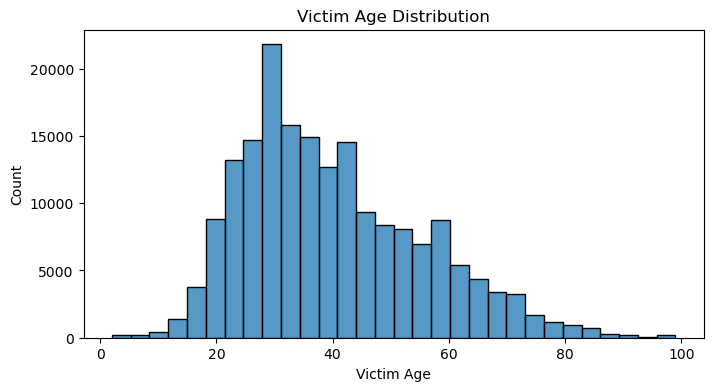

In [84]:
plt.figure(figsize=(8, 4))

sns.histplot(df_clean["Vict Age"], bins=30)

plt.title("Victim Age Distribution")
plt.xlabel("Victim Age")
plt.ylabel("Count")
plt.show()

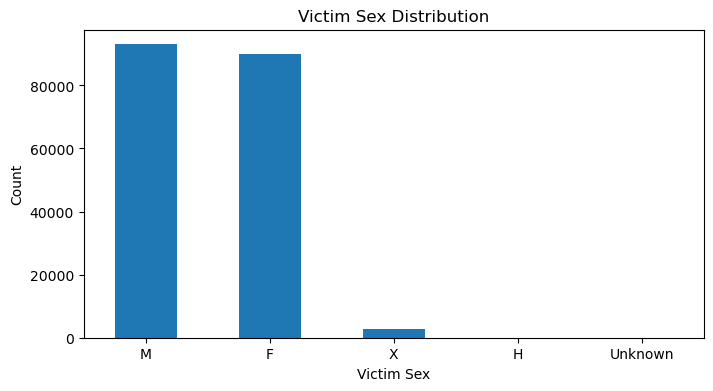

In [88]:
plt.figure(figsize=(8, 4))

df_clean["Vict Sex"].value_counts().plot(kind="bar")

plt.title("Victim Sex Distribution")
plt.xlabel("Victim Sex")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

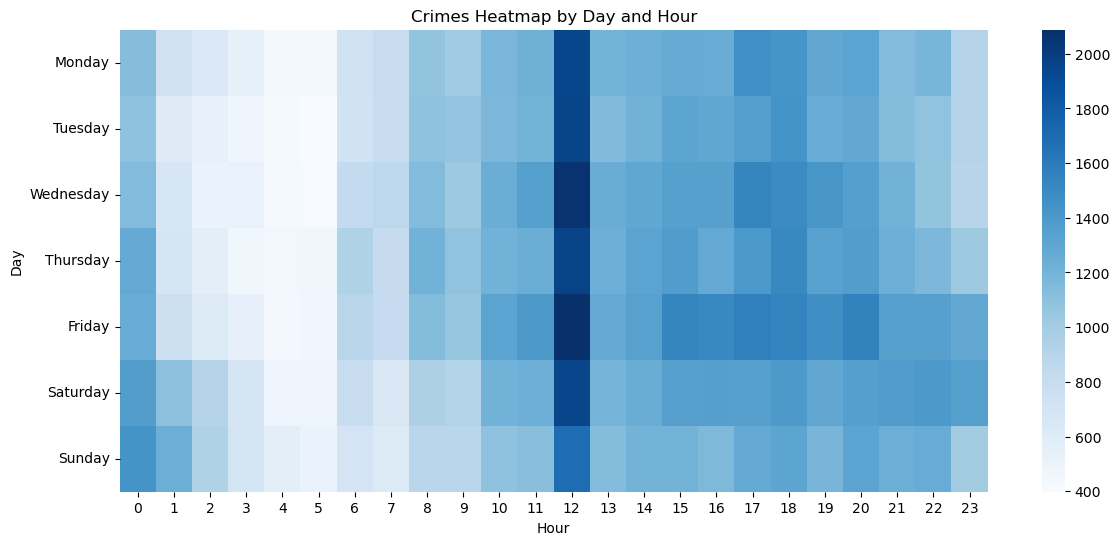

In [90]:
pivot_day_hour = df_clean.pivot_table(
    index="Day Name",
    columns="Hour",
    values="DR_NO",
    aggfunc="count"
)

pivot_day_hour = pivot_day_hour.reindex(days_order)

plt.figure(figsize=(14, 6))

sns.heatmap(pivot_day_hour, cmap="Blues")

plt.title("Crimes Heatmap by Day and Hour")
plt.xlabel("Hour")
plt.ylabel("Day")
plt.show()